**What if you update the CSV?**

Sometimes Pandas uses an old cached file.
To avoid this, add ?raw=1 at the end:
url = "https://raw.githubusercontent.com/.../yourfile.csv?raw=1"
This forces Colab to download the latest version.



**If CSV has Unicode issues**

Example: Bengali, Arabic, special symbols.
Then use:
df = pd.read_csv(url, encoding='utf-8')

**Load Excel files from GitHub**

If you upload .xlsx to GitHub:
df = pd.read_excel(url, engine='openpyxl')


**Store Your Token in Colab (Secure Method)**

In Colab:
import getpass
token = getpass.getpass("Enter your GitHub token: ")



In [ ]:
from collections import UserList
import pandas as pd

url = "https://raw.githubusercontent.com/shafiqulSQL/datascience-practice/refs/heads/main/data/raw/netflix1.csv?raw=1"

df = pd.read_csv(url)

df.head()
df.info()
#df.isnull().sum()
#df.isnull().mean() * 100

#df.duplicated().sum()

#df.describe(include='all')
#df.columns
#print("\n\n--------------")
#df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   country       8790 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   listed_in     8790 non-null   object
dtypes: int64(1), object(9)
memory usage: 686.8+ KB


In [ ]:
#Perform Data Cleaning
#Here is a basic cleaning template:

# Remove duplicate rows
df_clean = df.drop_duplicates()

# Strip extra spaces from text columns
df_clean = df_clean.apply(lambda col: col.str.strip() if col.dtype == "object" else col)

# Convert date columns (if any)
# df_clean['date_column'] = pd.to_datetime(df_clean['date_column'], errors='coerce')

# Remove rows with all null values
df_clean = df_clean.dropna(how='all')

# Reset index
df_clean = df_clean.reset_index(drop=True)

df_clean.head()
df_clean.info()

#Export the Cleaned File in Colab
df_clean.to_csv("cleaned_file.csv", index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   country       8790 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   listed_in     8790 non-null   object
dtypes: int64(1), object(9)
memory usage: 686.8+ KB


In [ ]:
import pandas as pd

ulr="https://raw.githubusercontent.com/shafiqulSQL/datascience-practice/refs/heads/main/data/cleaned/netflix1_cleaned_file.csv"

df=pd.read_csv(ulr)
df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   country       8790 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   listed_in     8790 non-null   object
dtypes: int64(1), object(9)
memory usage: 686.8+ KB


In [52]:
#Day 6 practice using ChatGPT

def get_pass_fail(score):
  if score >= 60:
    return "Pass"
  else:
    return "Fail"


def grade_category(score):
  match score:
    case score if score >= 90:
      return "A"
    case score if score >= 80:
      return "B"
    case score if score >= 70:
      return "C"
    case score if score >= 60:
      return "D"
    case _:
      return "F"

def age_group(age):
  if age <= 22:
    return "Young"
  else:
    return "Adult"


import pandas as pd

url="https://raw.githubusercontent.com/shafiqulSQL/datascience-practice/refs/heads/main/data/raw/students.csv"
df=pd.read_csv(url)

df["result"] = df["score"].apply(get_pass_fail)
df["grade"] = df["score"].apply(grade_category)
df["age_group"] = df["age"].apply(age_group)

#--Loop row by row (Simple & Readable)
print("All names who failed")
print ("="*30)
for indx, row in df.iterrows():
  if row['result'] == "Fail":
    print (row['name'])

#--Loop only values (faster & cleaner)
print("\n\nAll students with grade A")
print ("="*30)
for row in df.itertuples():
  if row.grade == "A":
    print (row.name)

#--Loop through specific columns only
print("\n\nAll students who are adults")
print ("="*30)
for age, name in zip(df['age'],df['name']):
  if age > 22:
    print (name)

#--Highest score
print("\n\n Highest score: ", df['score'].max())

#--Lowest score
print("\n\n Lowest score: ", df['score'].min())

#--Average score
print("\n\n Average score: ", df['score'].mean())

#--Count of pass vs fail
print("\n\n Count of pass vs fail")
print ("="*30)
print (df['result'].value_counts())
print(df.groupby('result')['id'].count())
print(df.groupby('result').size())

#--Number of A, B, C, D, F students
print("\n\n Number of A, B, C, D, F students")
print ("="*30)
print (df['grade'].value_counts())
print(df.groupby('grade')['id'].count().sort_values(ascending=False))
print(df.groupby('grade').count())

#--How many adults vs young
print("\n\n How many adults vs young")
print ("="*30)
print (df['age_group'].value_counts())
print(df.groupby('age_group')['id'].count())
print(df.groupby('age_group').size())

print("\n\n")
display (df)

df.to_csv("students_processed.csv", index=False)


All names who failed
Mina
Tom
Rob


All students with grade A
Sara
Lima


All students who are adults
Ali
John
Mina
Rob


 Highest score:  99


 Lowest score:  33


 Average score:  70.14285714285714


 Count of pass vs fail
result
Pass    4
Fail    3
Name: count, dtype: int64
result
Fail    3
Pass    4
Name: id, dtype: int64
result
Fail    3
Pass    4
dtype: int64


 Number of A, B, C, D, F students
grade
F    3
A    2
B    1
C    1
Name: count, dtype: int64
grade
F    3
A    2
B    1
C    1
Name: id, dtype: int64
       id  name  age  score  result  age_group
grade                                         
A       2     2    2      2       2          2
B       1     1    1      1       1          1
C       1     1    1      1       1          1
F       3     3    3      3       3          3


 How many adults vs young
age_group
Adult    4
Young    3
Name: count, dtype: int64
age_group
Adult    4
Young    3
Name: id, dtype: int64
age_group
Adult    4
Young    3
dtype: int64





,id,name,age,score,result,grade,age_group
0,1,Ali,23,88,Pass,B,Adult
1,2,Sara,22,91,Pass,A,Young
2,3,John,24,76,Pass,C,Adult
3,4,Mina,23,45,Fail,F,Adult
4,5,Tom,22,59,Fail,F,Young
5,6,Lima,21,99,Pass,A,Young
6,7,Rob,23,33,Fail,F,Adult


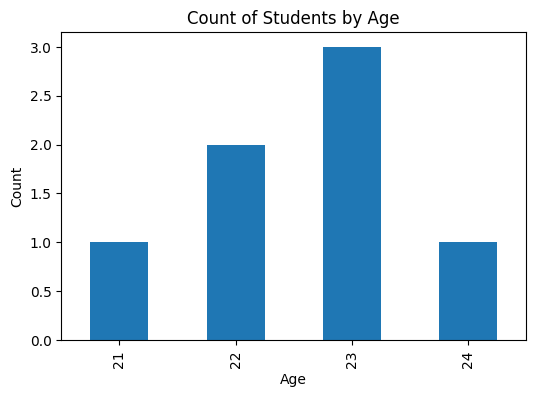

In [56]:
#--Day 7 — Data Visualization (Matplotlib + Seaborn Basics)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#--make plots visible inside notebook:
%matplotlib inline

url ='https://raw.githubusercontent.com/shafiqulSQL/datascience-practice/refs/heads/main/data/cleaned/students_processed.csv?raw=1'
df=pd.read_csv(url)

#--Plot 1 — Student Ages (Bar Chart)
#--Draw a bar chart of age count:

plt.figure(figsize=(6,4))
df['age'].value_counts().sort_index().plot(kind='bar')
plt.title("Count of Students by Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()
